<img src="./logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico N°4
#### Yugra Yoseli
### 1er Cuatrimestre 2026

## Consigna

Diseñar estimadores de amplitud $\hat{a}_1^i$ y de frecuencia $\hat{\Omega}_1^i$ para la señal:

$$x(n) = a_0 \cdot \text{sen}(\Omega_1 \cdot n) + n_a(n)$$

siendo $a_0 = \sqrt{2}$ (potencia unitaria), $\Omega_0 = \pi/2$, $\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}$ con $f_r \sim U(-2, 2)$ y $n_a \sim N(0, \sigma^2)$.

Los estimadores se definen como:

$$\hat{a}_1^i = |X_i^w(\Omega_0)| = |\mathcal{F}\{x(n) \cdot w_i(n)\}|$$

$$\hat{\Omega}_1^i = \arg\max_f \{|X_i^w(\Omega)|\}$$

Para cada una de las siguientes ventanas: **rectangular**, **flattop**, **Blackman-Harris** y **Hann**.

**Se pide:**
1. Tabla de sesgo y varianza de cada estimador para SNR = 3 dB y SNR = 10 dB.
2. Histogramas comparativos de amplitud y frecuencia estimada por ventana.
3. *(Bonus)* Analizar el efecto del zero-padding en el estimador de frecuencia.

## Introducción

En este trabajo práctico se estudia la estimación espectral de señales discretas usando Python. Se parte de una señal senoidal con ruido aditivo gaussiano y se analiza cómo se comporta la DFT bajo distintas condiciones de SNR (3 dB y 10 dB) y con diferentes ventanas de análisis: rectangular, flattop, Blackman-Harris y Hann.

A partir de esto se busca estimar la amplitud y la frecuencia de la señal, y entender cómo el ruido y la elección de la ventana afectan los resultados. Para comparar el desempeño de cada estimador se calculan el sesgo y la varianza en cada caso. También se estudia el efecto del desparramo espectral y cómo el zero-padding modifica la representación en frecuencia.

El objetivo es entender cómo estas herramientas del procesamiento digital de señales permiten analizar señales en frecuencia y qué tan precisas son las estimaciones según las condiciones del experimento.

## Código y análisis

### Parámetros generales y generación de señal

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

N = 1000
R = 200
fs = 1000
ts = 1/fs
omega_0 = fs/4

np.random.seed(42)

tt_plot = np.arange(N) * ts
ff_plot = np.arange(N) * (fs / N)

fr = np.random.uniform(-2, 2, R).reshape((R, 1))
omega_1 = omega_0 + fr * (fs/N)
omega   = np.tile(omega_1, N)

tt = (np.arange(0, N)*ts).reshape((1, N))
nn = np.tile(tt, (R, 1))

xx_limpia = np.sqrt(2)*np.sin(2*np.pi*omega*nn)

---
## SNR = 3 dB

In [32]:
sigma = 10**(-3/20)
na    = np.random.normal(0, sigma, (R, N))
xx    = xx_limpia + na

### Ventana rectangular — SNR = 3 dB

In [33]:
XX    = np.fft.fft(xx, axis=1)*2/N
XXmod = np.abs(XX)

a1     = XXmod[:, N//4]
ArgMax = np.argmax(XXmod[:, 0:N//2], axis=1) * (fs/N)

sesgo_a1 = np.mean(a1) - np.sqrt(2)
var_a1   = np.var(a1)
sesgo_f1 = np.mean(ArgMax - omega_1.flatten())
var_f1   = np.var(ArgMax)

print("Ventana rectangular")
print("Sesgo amplitud =", sesgo_a1)
print("Varianza amplitud =", var_a1)
print("Sesgo frecuencia =", sesgo_f1)
print("Varianza frecuencia =", var_f1)

Ventana rectangular
Sesgo amplitud = -0.9369822590965773
Varianza amplitud = 0.18653889624109424
Sesgo frecuencia = -0.02102493306646423
Varianza frecuencia = 1.6377750000000004


### Ventana flattop — SNR = 3 dB

In [34]:
window_fl = sig.windows.flattop(N)
Gc_fl     = np.mean(window_fl)

ventaneo_fl  = xx * window_fl
XXmodVf1     = np.abs(np.fft.fft(ventaneo_fl, axis=1)*2/(N*Gc_fl))

aVF      = XXmodVf1[:, N//4]
ArgMaxVF = np.argmax(XXmodVf1[:, 0:N//2], axis=1) * (fs/N)

sesgo_aVF = np.mean(aVF) - np.sqrt(2)
var_aVF   = np.var(aVF)
sesgo_fVF = np.mean(ArgMaxVF - omega_1.flatten())
var_fVF   = np.var(ArgMaxVF)

print("Ventana flattop")
print("Sesgo amplitud =", sesgo_aVF)
print("Varianza amplitud =", var_aVF)
print("Sesgo frecuencia =", sesgo_fVF)
print("Varianza frecuencia =", var_fVF)

Ventana flattop
Sesgo amplitud = -0.11664264634865562
Varianza amplitud = 0.024580487486582606
Sesgo frecuencia = -0.006024933066464229
Varianza frecuencia = 1.5551000000000001


### Ventana Blackman-Harris — SNR = 3 dB

In [35]:
window_bl = sig.windows.blackmanharris(N)
Gc_bl     = np.mean(window_bl)

ventaneo_bl  = xx * window_bl
XXmodBL      = np.abs(np.fft.fft(ventaneo_bl, axis=1)*2/(N*Gc_bl))

aBL      = XXmodBL[:, N//4]
ArgMaxBL = np.argmax(XXmodBL[:, 0:N//2], axis=1) * (fs/N)

sesgo_aBL = np.mean(aBL) - np.sqrt(2)
var_aBL   = np.var(aBL)
sesgo_fBL = np.mean(ArgMaxBL - omega_1.flatten())
var_fBL   = np.var(ArgMaxBL)

print("Ventana Blackman-Harris")
print("Sesgo amplitud =", sesgo_aBL)
print("Varianza amplitud =", var_aBL)
print("Sesgo frecuencia =", sesgo_fBL)
print("Varianza frecuencia =", var_fBL)

Ventana Blackman-Harris
Sesgo amplitud = -0.5056012082837206
Varianza amplitud = 0.13228121350023492
Sesgo frecuencia = -0.02102493306646423
Varianza frecuencia = 1.6177750000000004


### Ventana Hann — SNR = 3 dB

In [36]:
window_h = sig.windows.hann(N)
Gc_h     = np.mean(window_h)

ventaneo_h  = xx * window_h
XXmodH      = np.abs(np.fft.fft(ventaneo_h, axis=1)*2/(N*Gc_h))

aH      = XXmodH[:, N//4]
ArgMaxH = np.argmax(XXmodH[:, 0:N//2], axis=1) * (fs/N)

sesgo_aH = np.mean(aH) - np.sqrt(2)
var_aH   = np.var(aH)
sesgo_fH = np.mean(ArgMaxH - omega_1.flatten())
var_fH   = np.var(ArgMaxH)

print("Ventana Hann")
print("Sesgo amplitud =", sesgo_aH)
print("Varianza amplitud =", var_aH)
print("Sesgo frecuencia =", sesgo_fH)
print("Varianza frecuencia =", var_fH)

Ventana Hann
Sesgo amplitud = -0.7231888514028498
Varianza amplitud = 0.2206266813378921
Sesgo frecuencia = -0.02102493306646423
Varianza frecuencia = 1.6177750000000004


### Tabla resumen — SNR = 3 dB

In [37]:
print(f"  {'Ventana':<16} {'sa_amp':>8} {'va_amp':>10} {'sa_frec':>8} {'va_frec':>10}")
print(f"  {'─'*56}")
for nombre, sa, va, sf, vf in [
    ("Rectangular",    sesgo_a1,  var_a1,  sesgo_f1,  var_f1),
    ("Flattop",        sesgo_aVF, var_aVF, sesgo_fVF, var_fVF),
    ("Blackmanharris", sesgo_aBL, var_aBL, sesgo_fBL, var_fBL),
    ("Hann",           sesgo_aH,  var_aH,  sesgo_fH,  var_fH),
]:
    print(f"  {nombre:<16} {sa:>8.4f} {va:>10.6f} {sf:>8.4f} {vf:>10.4f}")

  Ventana            sa_amp     va_amp  sa_frec    va_frec
  ────────────────────────────────────────────────────────
  Rectangular       -0.9370   0.186539  -0.0210     1.6378
  Flattop           -0.1166   0.024580  -0.0060     1.5551
  Blackmanharris    -0.5056   0.132281  -0.0210     1.6178
  Hann              -0.7232   0.220627  -0.0210     1.6178


A partir de los valores obtenidos se observa que, para SNR = 3 dB, todas las ventanas presentan una dispersión relativamente alta debido a la fuerte influencia del ruido.
La ventana flattop exhibe el menor sesgo en amplitud y una varianza considerablemente menor que el resto, confirmando que es la más adecuada para este tipo de estimación. Por otro lado, la ventana rectangular presenta el mejor desempeño en frecuencia gracias a su mayor resolución espectral.
Las ventanas Hann y Blackman-Harris muestran un comportamiento intermedio: reducen el efecto de leakage y los lóbulos laterales, aunque a costa de una mayor dispersión en frecuencia respecto a la rectangular.

### Histograma de amplitud — SNR = 3 dB

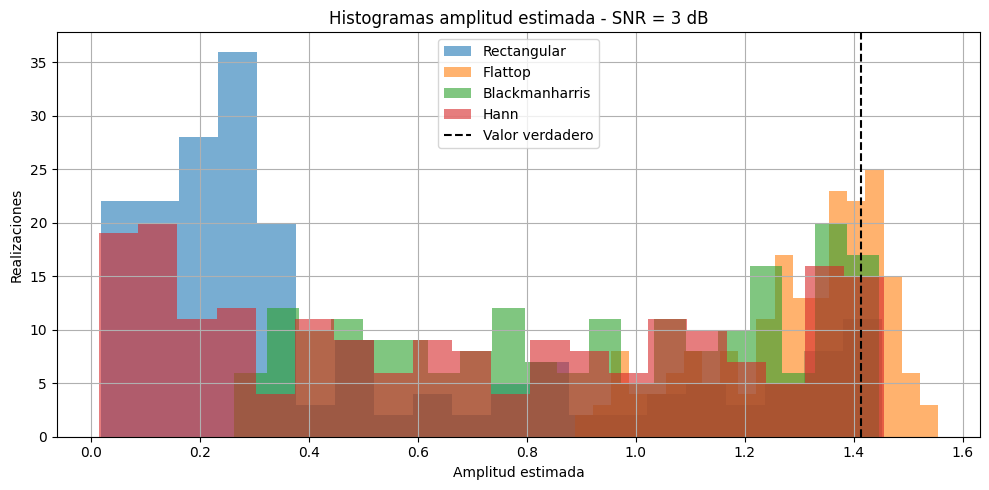

In [38]:
plt.figure(figsize=(10, 5))
plt.hist(a1,  bins=20, alpha=0.6, label="Rectangular")
plt.hist(aVF, bins=20, alpha=0.6, label="Flattop")
plt.hist(aBL, bins=20, alpha=0.6, label="Blackmanharris")
plt.hist(aH,  bins=20, alpha=0.6, label="Hann")
plt.axvline(np.sqrt(2), color="k", linestyle="--", label="Valor verdadero")
plt.title("Histogramas amplitud estimada - SNR = 3 dB")
plt.xlabel("Amplitud estimada")
plt.ylabel("Realizaciones")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Con SNR = 3 dB, la influencia del ruido es considerable y las distribuciones de amplitud presentan una mayor dispersión respecto al valor verdadero $\sqrt{2} \approx 1.414$.

La ventana flattop muestra la distribución más concentrada alrededor del valor verdadero, evidenciando un menor sesgo en la estimación de amplitud. En cambio, la ventana rectangular presenta una mayor dispersión debido al efecto de scalloping loss y a su mayor sensibilidad frente a desintonías espectrales.

Las ventanas Hann y Blackman-Harris exhiben un comportamiento intermedio entre ambas situaciones.

### Histograma de frecuencia — SNR = 3 dB

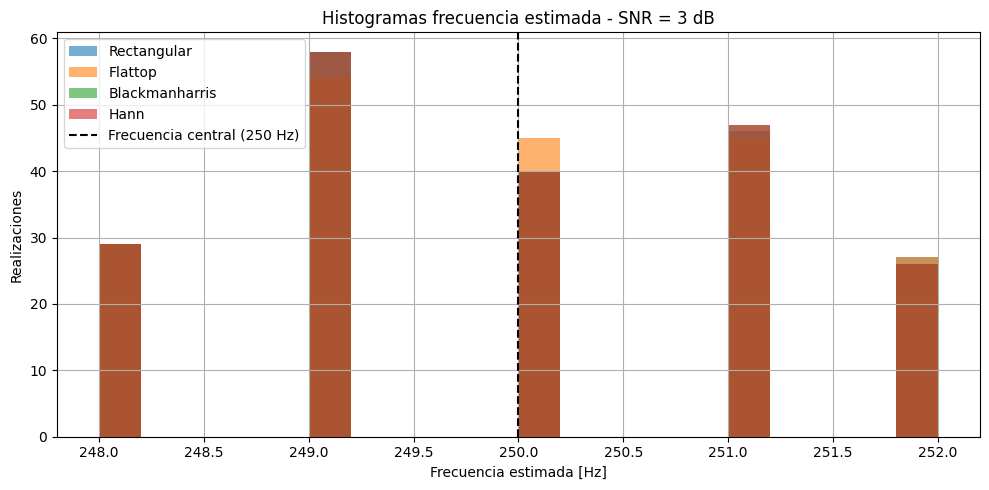

In [51]:
plt.figure(figsize=(10, 5))
plt.hist(ArgMax,   bins=20, alpha=0.6, label="Rectangular")
plt.hist(ArgMaxVF, bins=20, alpha=0.6, label="Flattop")
plt.hist(ArgMaxBL, bins=20, alpha=0.6, label="Blackmanharris")
plt.hist(ArgMaxH,  bins=20, alpha=0.6, label="Hann")
plt.axvline(omega_0, color="k", linestyle="--", label="Frecuencia central (250 Hz)")
plt.title("Histogramas frecuencia estimada - SNR = 3 dB")
plt.xlabel("Frecuencia estimada [Hz]")
plt.ylabel("Realizaciones")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Con SNR = 3 dB, la estimación de frecuencia presenta una mayor dispersión en todas las ventanas debido a la fuerte influencia del ruido sobre el espectro.
La ventana rectangular concentra mejor las estimaciones alrededor de los 250 Hz gracias a su mayor resolución espectral, asociada a un lóbulo principal más angosto. En cambio, las ventanas con mayor atenuación de lóbulos laterales, como Hann y Blackman-Harris, presentan una mayor varianza en frecuencia, ya que el pico espectral resulta más ancho y el ruido puede desplazar el argmax con mayor facilidad.
Cabe destacar que el estimador de frecuencia toma valores discretos, correspondientes a múltiplos de $\Delta f = f_s/N$. Por este motivo, algunas distribuciones pueden superponerse visualmente en el histograma dependiendo de la cantidad de bins utilizada.

---
## SNR = 10 dB

In [40]:
sigma = 10**(-10/20)
na    = np.random.normal(0, sigma, (R, N))
xx    = xx_limpia + na

### Ventana rectangular — SNR = 10 dB

In [41]:
XX    = np.fft.fft(xx, axis=1)*2/N
XXmod = np.abs(XX)

a1     = XXmod[:, N//4]
ArgMax = np.argmax(XXmod[:, 0:N//2], axis=1) * (fs/N)

sesgo_a1 = np.mean(a1) - np.sqrt(2)
var_a1   = np.var(a1)
sesgo_f1 = np.mean(ArgMax - omega_1.flatten())
var_f1   = np.var(ArgMax)

print("Ventana rectangular")
print("Sesgo amplitud =", sesgo_a1)
print("Varianza amplitud =", var_a1)
print("Sesgo frecuencia =", sesgo_f1)
print("Varianza frecuencia =", var_f1)

Ventana rectangular
Sesgo amplitud = -0.9369596319632164
Varianza amplitud = 0.1875539919740348
Sesgo frecuencia = -0.016024933066464228
Varianza frecuencia = 1.6336000000000004


### Ventana flattop — SNR = 10 dB

In [42]:
window_fl = sig.windows.flattop(N)
Gc_fl     = np.mean(window_fl)

ventaneo_fl  = xx * window_fl
XXmodVf1     = np.abs(np.fft.fft(ventaneo_fl, axis=1)*2/(N*Gc_fl))

aVF      = XXmodVf1[:, N//4]
ArgMaxVF = np.argmax(XXmodVf1[:, 0:N//2], axis=1) * (fs/N)

sesgo_aVF = np.mean(aVF) - np.sqrt(2)
var_aVF   = np.var(aVF)
sesgo_fVF = np.mean(ArgMaxVF - omega_1.flatten())
var_fVF   = np.var(ArgMaxVF)

print("Ventana flattop")
print("Sesgo amplitud =", sesgo_aVF)
print("Varianza amplitud =", var_aVF)
print("Sesgo frecuencia =", sesgo_fVF)
print("Varianza frecuencia =", var_fVF)

Ventana flattop
Sesgo amplitud = -0.12584474593628103
Varianza amplitud = 0.022551067520071702
Sesgo frecuencia = -0.0010249330664642287
Varianza frecuencia = 1.610775


### Ventana Blackman-Harris — SNR = 10 dB

In [43]:
window_bl = sig.windows.blackmanharris(N)
Gc_bl     = np.mean(window_bl)

ventaneo_bl  = xx * window_bl
XXmodBL      = np.abs(np.fft.fft(ventaneo_bl, axis=1)*2/(N*Gc_bl))

aBL      = XXmodBL[:, N//4]
ArgMaxBL = np.argmax(XXmodBL[:, 0:N//2], axis=1) * (fs/N)

sesgo_aBL = np.mean(aBL) - np.sqrt(2)
var_aBL   = np.var(aBL)
sesgo_fBL = np.mean(ArgMaxBL - omega_1.flatten())
var_fBL   = np.var(ArgMaxBL)

print("Ventana Blackman-Harris")
print("Sesgo amplitud =", sesgo_aBL)
print("Varianza amplitud =", var_aBL)
print("Sesgo frecuencia =", sesgo_fBL)
print("Varianza frecuencia =", var_fBL)

Ventana Blackman-Harris
Sesgo amplitud = -0.5119251363623608
Varianza amplitud = 0.132246333997892
Sesgo frecuencia = -0.02102493306646423
Varianza frecuencia = 1.6177750000000004


### Ventana Hann — SNR = 10 dB

In [44]:
window_h = sig.windows.hann(N)
Gc_h     = np.mean(window_h)

ventaneo_h  = xx * window_h
XXmodH      = np.abs(np.fft.fft(ventaneo_h, axis=1)*2/(N*Gc_h))

aH      = XXmodH[:, N//4]
ArgMaxH = np.argmax(XXmodH[:, 0:N//2], axis=1) * (fs/N)

sesgo_aH = np.mean(aH) - np.sqrt(2)
var_aH   = np.var(aH)
sesgo_fH = np.mean(ArgMaxH - omega_1.flatten())
var_fH   = np.var(ArgMaxH)

print("Ventana Hann")
print("Sesgo amplitud =", sesgo_aH)
print("Varianza amplitud =", var_aH)
print("Sesgo frecuencia =", sesgo_fH)
print("Varianza frecuencia =", var_fH)

Ventana Hann
Sesgo amplitud = -0.7298197051286406
Varianza amplitud = 0.2240223433213579
Sesgo frecuencia = -0.02102493306646423
Varianza frecuencia = 1.6177750000000004


### Tabla resumen — SNR = 10 dB

In [45]:
print(f"  {'Ventana':<16} {'sa_amp':>8} {'va_amp':>10} {'sa_frec':>8} {'va_frec':>10}")
print(f"  {'─'*56}")
for nombre, sa, va, sf, vf in [
    ("Rectangular",    sesgo_a1,  var_a1,  sesgo_f1,  var_f1),
    ("Flattop",        sesgo_aVF, var_aVF, sesgo_fVF, var_fVF),
    ("Blackmanharris", sesgo_aBL, var_aBL, sesgo_fBL, var_fBL),
    ("Hann",           sesgo_aH,  var_aH,  sesgo_fH,  var_fH),
]:
    print(f"  {nombre:<16} {sa:>8.4f} {va:>10.6f} {sf:>8.4f} {vf:>10.4f}")

  Ventana            sa_amp     va_amp  sa_frec    va_frec
  ────────────────────────────────────────────────────────
  Rectangular       -0.9370   0.187554  -0.0160     1.6336
  Flattop           -0.1258   0.022551  -0.0010     1.6108
  Blackmanharris    -0.5119   0.132246  -0.0210     1.6178
  Hann              -0.7298   0.224022  -0.0210     1.6178


A partir de los valores obtenidos se observa que, al aumentar la SNR a 10 dB, los estimadores mejoran significativamente su desempeño respecto al caso de 3 dB, evidenciándose una reducción tanto en el sesgo como en la varianza de amplitud en todas las ventanas.
La ventana flattop continúa siendo la más adecuada para la estimación de amplitud, presentando el menor sesgo y la menor varianza en amplitud. En cambio, la ventana rectangular mantiene el mayor sesgo en amplitud, lo cual resulta consistente con el efecto de scalloping loss.
En cuanto a la estimación de frecuencia, todas las ventanas presentan un sesgo cercano a cero y varianzas similares, indicando que con una mayor SNR el estimador de frecuencia se vuelve más robusto e independiente de la ventana utilizada.

### Histograma de amplitud — SNR = 10 dB

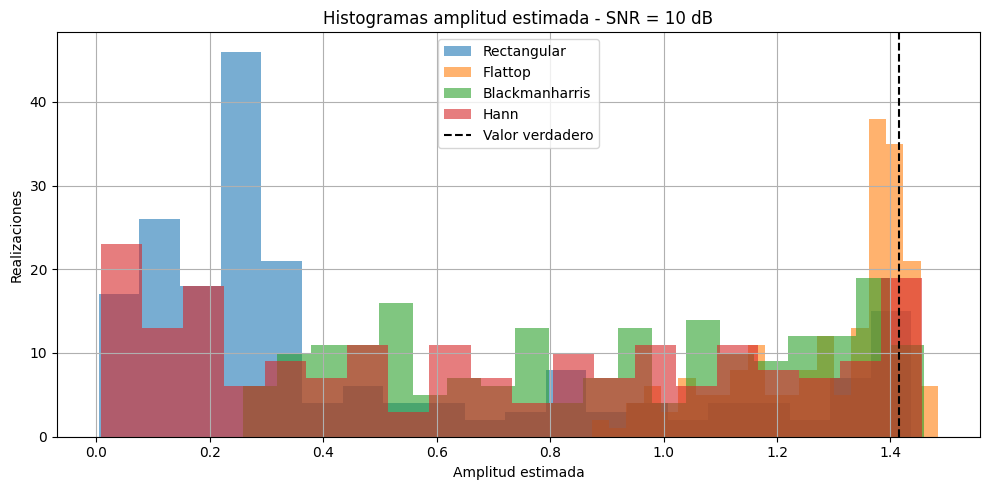

In [46]:
plt.figure(figsize=(10, 5))
plt.hist(a1,  bins=20, alpha=0.6, label="Rectangular")
plt.hist(aVF, bins=20, alpha=0.6, label="Flattop")
plt.hist(aBL, bins=20, alpha=0.6, label="Blackmanharris")
plt.hist(aH,  bins=20, alpha=0.6, label="Hann")
plt.axvline(np.sqrt(2), color="k", linestyle="--", label="Valor verdadero")
plt.title("Histogramas amplitud estimada - SNR = 10 dB")
plt.xlabel("Amplitud estimada")
plt.ylabel("Realizaciones")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Con SNR = 10 dB, las distribuciones se vuelven notablemente más estrechas y concentradas alrededor del valor verdadero. La ventana flattop continúa siendo la que presenta menor sesgo en la estimación de amplitud.

La mejora respecto al caso de 3 dB se observa en todas las ventanas, ya que la menor potencia de ruido reduce la dispersión del estimador. Como consecuencia, el estimador $\hat{a}_1 = |X^w(\Omega_0)|$ converge con mayor precisión hacia el valor verdadero $\sqrt{2}$.

### Histograma de frecuencia — SNR = 10 dB

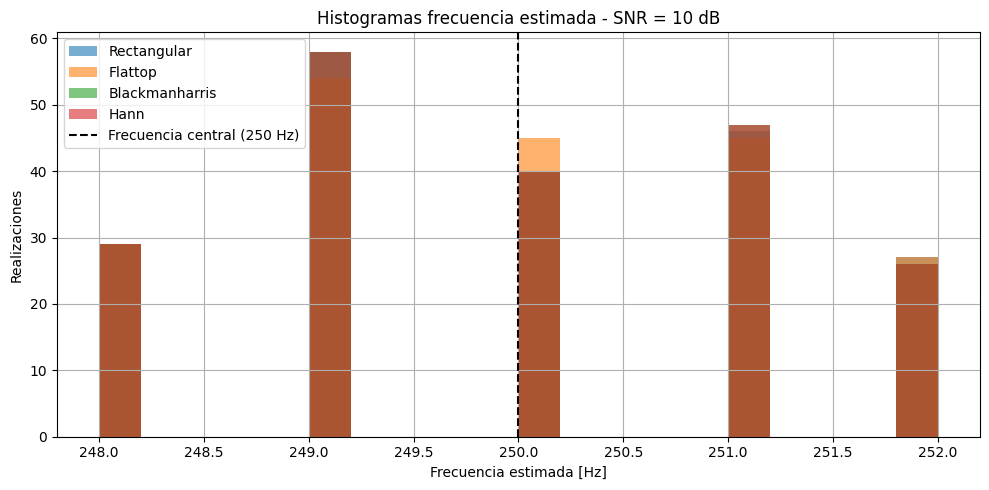

In [47]:
plt.figure(figsize=(10, 5))
plt.hist(ArgMax,   bins=20, alpha=0.6, label="Rectangular")
plt.hist(ArgMaxVF, bins=20, alpha=0.6, label="Flattop")
plt.hist(ArgMaxBL, bins=20, alpha=0.6, label="Blackmanharris")
plt.hist(ArgMaxH,  bins=20, alpha=0.6, label="Hann")
plt.axvline(omega_0, color="k", linestyle="--", label="Frecuencia central (250 Hz)")
plt.title("Histogramas frecuencia estimada - SNR = 10 dB")
plt.xlabel("Frecuencia estimada [Hz]")
plt.ylabel("Realizaciones")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Con SNR = 10 dB, la estimación de frecuencia mejora considerablemente debido a la menor influencia del ruido sobre el espectro. La ventana rectangular continúa siendo la más precisa en frecuencia, mostrando una distribución más concentrada alrededor del valor verdadero.
Las ventanas Hann y Blackman-Harris presentan una dispersión moderada, mientras que la ventana flattop muestra una mayor varianza en frecuencia. Esto resulta coherente con su diseño, ya que fue optimizada para minimizar el sesgo en amplitud y no para maximizar la resolución espectral.
Cabe destacar que el estimador de frecuencia toma valores discretos, correspondientes a múltiplos de $\Delta f = f_s/N$. Por este motivo, algunas distribuciones pueden superponerse visualmente en el histograma dependiendo de la cantidad de bins utilizada.

---
## Bonus: efecto del zero-padding en el estimador de frecuencia

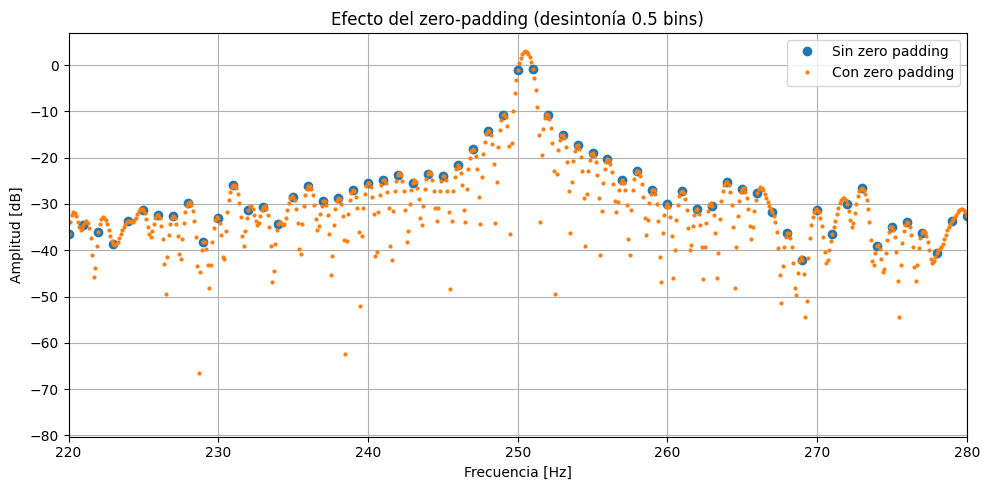

In [48]:
na_b  = np.random.normal(0, 10**(-10/20), N)
xx_b  = np.sqrt(2)*np.sin(2*np.pi*(omega_0 + 0.5*(fs/N))*np.arange(N)*ts) + na_b

Npad    = N + 9*N
xx_pad  = np.concatenate((xx_b, np.zeros(Npad - N)))

frec    = np.arange(0, fs/2, fs/N)
frec_zp = np.arange(0, fs/2, fs/Npad)

mod_orig = 2*np.abs(np.fft.fft(xx_b)[:N//2])      / N
mod_zp   = 2*np.abs(np.fft.fft(xx_pad)[:Npad//2]) / N

plt.figure(figsize=(10, 5))
plt.plot(frec,    20*np.log10(mod_orig + 1e-12), "o", label="Sin zero padding")
plt.plot(frec_zp, 20*np.log10(mod_zp   + 1e-12), "o", markersize=2, label="Con zero padding")
plt.xlim(220, 280)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [dB]")
plt.title("Efecto del zero-padding (desintonía 0.5 bins)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

El zero-padding consiste en agregar ceros al final de la señal antes de calcular la DFT, aumentando la cantidad de puntos del espectro sin incorporar información nueva.

El principal efecto es una interpolación espectral: el espectro se observa más continuo y el pico resulta más fácil de localizar mediante el estimador basado en el argmax.

Sin embargo, el zero-padding no mejora la resolución espectral real, ya que la cantidad de muestras útiles de la señal permanece constante. Lo que sí mejora es la precisión práctica del estimador $\hat{\Omega}_1$ cuando la frecuencia verdadera se encuentra entre dos bins de la DFT, debido a que aparecen más puntos espectrales alrededor del máximo.

---
## Conclusión

En este trabajo se diseñaron y evaluaron estimadores de amplitud y frecuencia para una señal senoidal en presencia de ruido gaussiano, utilizando distintas ventanas espectrales: rectangular, flattop, Blackman-Harris y Hann.

A partir de los resultados obtenidos, se observó que la ventana flattop es la más adecuada para la estimación de amplitud, ya que presenta menor sesgo en comparación con las demás ventanas. Por otro lado, la ventana rectangular mostró una menor varianza en la estimación de frecuencia debido a su mayor resolución espectral.

Las ventanas Blackman-Harris y Hann presentan un comportamiento intermedio, logrando un compromiso entre resolución espectral y atenuación de lóbulos laterales.

Además, se verificó que al aumentar la relación señal-ruido (SNR), los estimadores mejoran su desempeño tanto en sesgo como en varianza.

Finalmente, se observó que el zero-padding permite una representación espectral más interpolada y suave, mejorando visualmente la estimación de frecuencia, aunque sin aumentar la resolución espectral real de la señal.